# Portfolio Optimization with Modern Portfolio Theory

This notebook demonstrates the application of Modern Portfolio Theory for portfolio optimization using both classical MPT and machine learning enhanced approaches.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_collector import DataCollector
from src.portfolio_optimizer import ModernPortfolioTheory
from src.ml_portfolio_optimizer import MLPortfolioOptimizer

plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load Market Data

In [2]:
collector = DataCollector()

# Multi-Asset Portfolio: Stocks, Bonds, Commodities, International
tickers = [
    # Large Cap Tech
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA',
    # Value & Dividend Stocks  
    'JPM', 'JNJ', 'V', 'PG', 'HD', 'UNH',
    # Growth Stocks
    'DIS', 'ADBE', 'CRM', 'NFLX', 'COST',
    # Treasury Bonds
    'TLT',   # 20+ Year Treasury Bond ETF
    'IEF',   # 7-10 Year Treasury Bond ETF  
    'SHY',   # 1-3 Year Treasury Bond ETF
    # Corporate Bonds
    'LQD',   # Investment Grade Corporate Bond ETF
    'HYG',   # High Yield Corporate Bond ETF
    # Commodities & Alternative Assets
    'GLD',   # Gold ETF
    'SLV',   # Silver ETF
    'USO',   # Oil ETF
    # International Exposure
    'VEA',   # Developed Markets ETF
    'VWO',   # Emerging Markets ETF
    # REITs
    'VNQ'    # Real Estate Investment Trust ETF
]

print(f"Multi-Asset Portfolio: {len(tickers)} assets across:")
print("- Equities (16): Tech, Value, Growth")  
print("- Fixed Income (5): Treasury & Corporate Bonds")
print("- Commodities (3): Gold, Silver, Oil")
print("- International (2): Developed & Emerging Markets")
print("- REITs (1): Real Estate")

price_data = collector.fetch_stock_data(tickers, period='2y')
print(f"\nData loaded for {len(tickers)} assets from {price_data.index[0]} to {price_data.index[-1]}")
print(f"Shape: {price_data.shape}")

price_data.tail()

Multi-Asset Portfolio: 27 assets across:
- Equities (16): Tech, Value, Growth
- Fixed Income (5): Treasury & Corporate Bonds
- Commodities (3): Gold, Silver, Oil
- International (2): Developed & Emerging Markets
- REITs (1): Real Estate
Loading data for ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'JNJ', 'V', 'PG', 'HD', 'UNH', 'DIS', 'ADBE', 'CRM', 'NFLX', 'COST', 'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'GLD', 'SLV', 'USO', 'VEA', 'VWO', 'VNQ'] over 2y...
Raw data shape: (501, 135)
Columns: [('Close', 'AAPL'), ('Close', 'ADBE'), ('Close', 'AMZN'), ('Close', 'COST'), ('Close', 'CRM'), ('Close', 'DIS'), ('Close', 'GLD'), ('Close', 'GOOGL'), ('Close', 'HD'), ('Close', 'HYG'), ('Close', 'IEF'), ('Close', 'JNJ'), ('Close', 'JPM'), ('Close', 'LQD'), ('Close', 'MSFT'), ('Close', 'NFLX'), ('Close', 'NVDA'), ('Close', 'PG'), ('Close', 'SHY'), ('Close', 'SLV'), ('Close', 'TLT'), ('Close', 'UNH'), ('Close', 'USO'), ('Close', 'V'), ('Close', 'VEA'), ('Close', 'VNQ'), ('Close', 'VWO'), ('High', 'AA

Ticker,AAPL,ADBE,AMZN,COST,CRM,DIS,GLD,GOOGL,HD,HYG,...,PG,SHY,SLV,TLT,UNH,USO,V,VEA,VNQ,VWO
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-22,258.450012,354.089996,217.949997,944.679993,256.640015,113.080002,377.279999,251.690002,388.970001,80.680000,...,151.143066,83.120003,43.880001,92.059998,361.489990,70.629997,345.359985,60.709999,92.220001,54.509998
2025-10-23,259.579987,354.119995,221.089996,942.049988,255.050003,113.029999,378.790009,253.080002,385.029999,80.860001,...,151.153000,83.059998,44.180000,91.430000,360.450012,73.290001,345.959991,61.020000,92.160004,54.919998
2025-10-24,262.820007,353.519989,224.210007,932.140015,254.830002,111.680000,377.519989,259.920013,386.679993,81.080002,...,152.490005,83.110001,43.990002,91.470001,362.500000,73.180000,347.380005,61.220001,92.430000,55.180000
2025-10-27,268.809998,357.799988,226.970001,929.849976,255.470001,112.339996,367.010010,269.269989,385.269989,81.279999,...,151.740005,83.089996,42.400002,91.779999,365.980011,73.120003,347.820007,61.669998,92.690002,55.639999
2025-10-28,269.000000,359.910004,229.250000,924.159973,254.259995,111.650002,364.380005,267.470001,385.750000,81.199997,...,151.369995,83.099998,42.700001,92.019997,367.839996,71.389999,346.899994,61.660000,90.870003,55.610001


## 2. Calculate Returns

Return Statistics (annualized):
Mean Return: Ticker
AAPL     27.46
ADBE    -13.97
AMZN     31.82
COST     29.64
CRM      17.89
DIS      20.96
GLD      35.64
GOOGL    42.91
HD       20.65
HYG      11.89
IEF       8.07
JNJ      16.69
JPM      44.83
LQD      11.21
MSFT     27.04
NFLX     54.98
NVDA     91.57
PG        4.68
SHY       5.15
SLV      39.16
TLT       9.77
UNH      -8.09
USO       1.19
V        22.58
VEA      23.43
VNQ      17.49
VWO      23.51
dtype: float64%
Volatility: Ticker
AAPL     27.83
ADBE     32.10
AMZN     29.13
COST     20.96
CRM      31.82
DIS      27.36
GLD      17.20
GOOGL    28.22
HD       21.42
HYG       4.94
IEF       6.69
JNJ      16.78
JPM      21.42
LQD       7.42
MSFT     21.83
NFLX     32.07
NVDA     48.06
PG       16.84
SHY       1.72
SLV      28.92
TLT      14.18
UNH      39.84
USO      29.58
V        18.84
VEA      14.59
VNQ      17.24
VWO      16.33
dtype: float64%


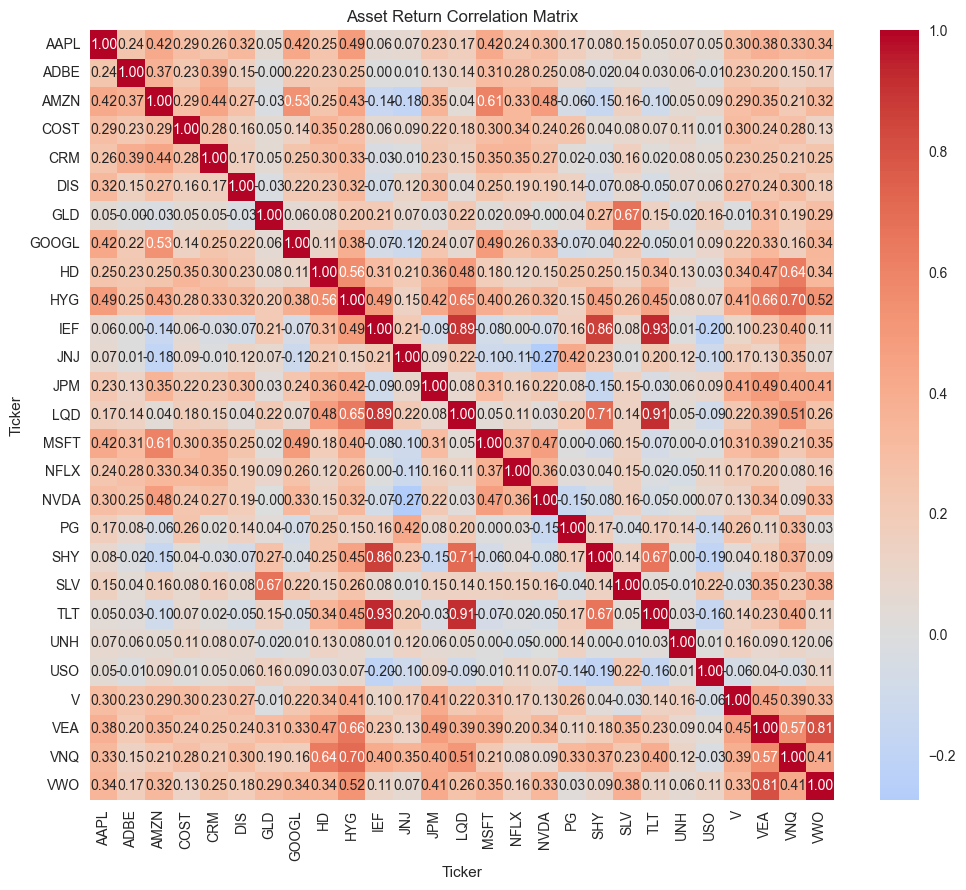

In [3]:
returns = collector.calculate_returns(method='simple')

print("Return Statistics (annualized):")
print(f"Mean Return: {(returns.mean() * 252 * 100).round(2)}%")
print(f"Volatility: {(returns.std() * np.sqrt(252) * 100).round(2)}%")

plt.figure(figsize=(12, 10))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Asset Return Correlation Matrix')
plt.show()

Asset Class Performance (Annualized):
Equities    :  27.0% return, 13.9% vol,  1.94 Sharpe
Bonds       :   9.2% return,  6.3% vol,  1.45 Sharpe
Commodities :  25.3% return, 18.9% vol,  1.34 Sharpe
International:  23.5% return, 14.7% vol,  1.60 Sharpe
REITs       :  17.5% return, 17.2% vol,  1.01 Sharpe

Cross-Asset Class Correlations:


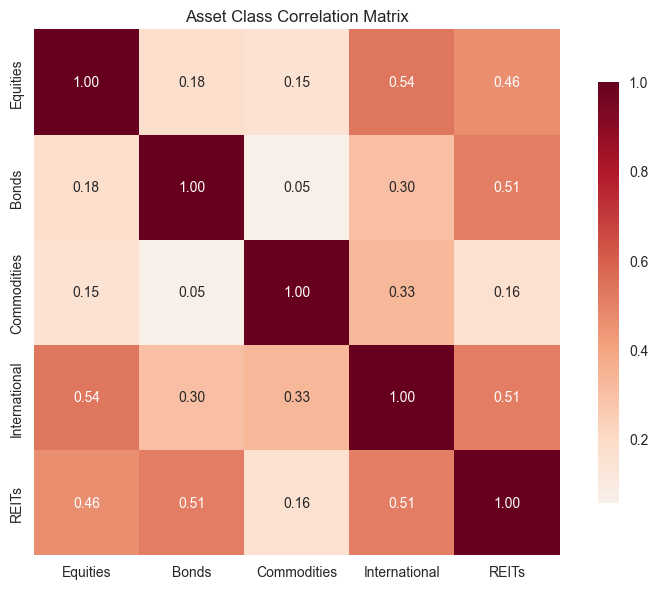

In [4]:
# Asset Class Analysis
asset_classes = {
    'Equities': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'JPM', 'JNJ', 'V', 'PG', 'HD', 'UNH', 'DIS', 'ADBE', 'CRM', 'NFLX', 'COST'],
    'Bonds': ['TLT', 'IEF', 'SHY', 'LQD', 'HYG'],
    'Commodities': ['GLD', 'SLV', 'USO'],
    'International': ['VEA', 'VWO'],
    'REITs': ['VNQ']
}

print("Asset Class Performance (Annualized):")
print("="*50)
for class_name, assets in asset_classes.items():
    available_assets = [a for a in assets if a in returns.columns]
    if available_assets:
        class_returns = returns[available_assets].mean(axis=1)
        annual_return = class_returns.mean() * 252
        annual_vol = class_returns.std() * np.sqrt(252)
        sharpe = annual_return / annual_vol if annual_vol > 0 else 0
        print(f"{class_name:<12}: {annual_return:>6.1%} return, {annual_vol:>5.1%} vol, {sharpe:>5.2f} Sharpe")

# Cross-Asset Class Correlations
print(f"\nCross-Asset Class Correlations:")
class_series = {}
for class_name, assets in asset_classes.items():
    available_assets = [a for a in assets if a in returns.columns]
    if available_assets:
        class_series[class_name] = returns[available_assets].mean(axis=1)

if len(class_series) > 1:
    class_df = pd.DataFrame(class_series)
    plt.figure(figsize=(8, 6))
    sns.heatmap(class_df.corr(), annot=True, cmap='RdBu_r', center=0, 
                square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title('Asset Class Correlation Matrix')
    plt.tight_layout()
    plt.show()

## 3. Classical Portfolio Optimization (MPT)

In [5]:
mpt = ModernPortfolioTheory(returns)

max_sharpe = mpt.max_sharpe_portfolio()
print("Maximum Sharpe Ratio Portfolio:")
print(f"Expected Return: {max_sharpe['return']:.2%}")
print(f"Volatility: {max_sharpe['volatility']:.2%}")
print(f"Sharpe Ratio: {max_sharpe['sharpe_ratio']:.3f}")
print("\nWeights:")
for asset, weight in max_sharpe['weights'].items():
    if weight > 0.01:
        print(f"{asset}: {weight:.1%}")

Maximum Sharpe Ratio Portfolio:
Expected Return: 37.57%
Volatility: 10.29%
Sharpe Ratio: 3.214

Weights:
COST: 2.0%
GLD: 29.0%
GOOGL: 5.0%
IEF: 11.2%
JNJ: 18.3%
JPM: 18.3%
NFLX: 6.8%
NVDA: 9.4%


In [6]:
min_vol = mpt.min_volatility_portfolio()
print("Minimum Volatility Portfolio:")
print(f"Expected Return: {min_vol['return']:.2%}")
print(f"Volatility: {min_vol['volatility']:.2%}")
print(f"Sharpe Ratio: {min_vol['sharpe_ratio']:.3f}")
print("\nWeights:")
for asset, weight in min_vol['weights'].items():
    if weight > 0.01:
        print(f"{asset}: {weight:.1%}")

Minimum Volatility Portfolio:
Expected Return: 5.80%
Volatility: 1.62%
Sharpe Ratio: 0.800

Weights:
JPM: 1.2%
SHY: 96.5%
USO: 1.2%


## 4. Efficient Frontier Visualization

In [ ]:
volatilities, target_returns = mpt.efficient_frontier(num_portfolios=50)

plt.figure(figsize=(12, 8))

valid_indices = ~np.isnan(volatilities)
plt.plot(volatilities[valid_indices], target_returns[valid_indices], 
         'b-', linewidth=2, label='Efficient Frontier')

for i, asset in enumerate(returns.columns):
    asset_return = mpt.mean_returns.iloc[i]
    asset_vol = np.sqrt(mpt.cov_matrix.iloc[i, i])
    plt.scatter(asset_vol, asset_return, s=100, alpha=0.7, label=asset)

plt.scatter(max_sharpe['volatility'], max_sharpe['return'], 
           s=200, c='red', marker='*', label='Max Sharpe')
plt.scatter(min_vol['volatility'], min_vol['return'], 
           s=200, c='green', marker='*', label='Min Volatility')

plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier and Asset Allocation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Machine Learning Enhanced Portfolio Optimization

In [8]:
ml_optimizer = MLPortfolioOptimizer(returns, price_data)

features = ml_optimizer.create_features()
print(f"Features created: {features.shape[1]} technical indicators")

print("\nTraining ML models for return prediction...")
models, predictions = ml_optimizer.predict_returns()

print(f"\nAverage R² Score: {np.mean([info['test_score'] for info in models.values()]):.3f}")

ml_weights = ml_optimizer.ml_portfolio_weights()
print(f"\nML Portfolio Weights:")
for asset, weight in ml_weights.items():
    if weight > 0.05:
        print(f"{asset}: {weight:.1%}")

importance = ml_optimizer.get_feature_importance(top_n=3)
print(f"\nTop Features for first 3 assets:")
for asset in list(importance.keys())[:3]:
    print(f"\n{asset} (R²: {importance[asset]['model_score']:.3f}):")
    for feature, imp in importance[asset]['top_features']:
        print(f"  - {feature}: {imp:.3f}")

Features created: 300 technical indicators

Training ML models for return prediction...
Training model for AAPL...
Training model for ADBE...
Training model for AMZN...
Training model for COST...
Training model for CRM...
Training model for DIS...
Training model for GLD...
Training model for GOOGL...
Training model for HD...
Training model for HYG...
Training model for IEF...
Training model for JNJ...
Training model for JPM...
Training model for LQD...
Training model for MSFT...
Training model for NFLX...
Training model for NVDA...
Training model for PG...
Training model for SHY...
Training model for SLV...
Training model for TLT...
Training model for UNH...
Training model for USO...
Training model for V...
Training model for VEA...
Training model for VNQ...
Training model for VWO...

Average R² Score: -0.235

ML Portfolio Weights:
IEF: 48.3%
LQD: 37.5%

Top Features for first 3 assets:

AAPL (R²: -0.432):
  - CRM_bb_position: 0.017
  - GOOGL_momentum_5: 0.012
  - ADBE_momentum_5: 0.01

## 6. Portfolio Performance Comparison

In [9]:
def calculate_portfolio_metrics(weights, returns_data):
    weights_series = pd.Series(weights)
    weights_series = weights_series / weights_series.sum()
    
    portfolio_return = (returns_data * weights_series).sum(axis=1)
    annual_return = portfolio_return.mean() * 252
    annual_vol = portfolio_return.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    return annual_return, annual_vol, sharpe

strategies = {
    'Equal Weight': {asset: 1/len(tickers) for asset in tickers},
    'Max Sharpe (MPT)': max_sharpe['weights'],
    'Min Volatility (MPT)': min_vol['weights'],
    'ML-Enhanced': ml_weights
}

print("Portfolio Performance Comparison:")
print("="*60)
print(f"{'Strategy':<20} {'Return':<10} {'Volatility':<12} {'Sharpe':<8}")
print("-"*60)

for name, weights in strategies.items():
    try:
        ret, vol, sharpe = calculate_portfolio_metrics(weights, returns)
        print(f"{name:<20} {ret:>8.1%} {vol:>10.1%} {sharpe:>10.3f}")
    except Exception as e:
        print(f"{name:<20} Calculation error")

Portfolio Performance Comparison:
Strategy             Return     Volatility   Sharpe  
------------------------------------------------------------
Equal Weight            22.9%      10.1%      2.256
Max Sharpe (MPT)        37.6%      10.3%      3.651
Min Volatility (MPT)     5.8%       1.6%      3.576
ML-Enhanced             11.4%       6.3%      1.817


## 7. Portfolio Weights Visualization

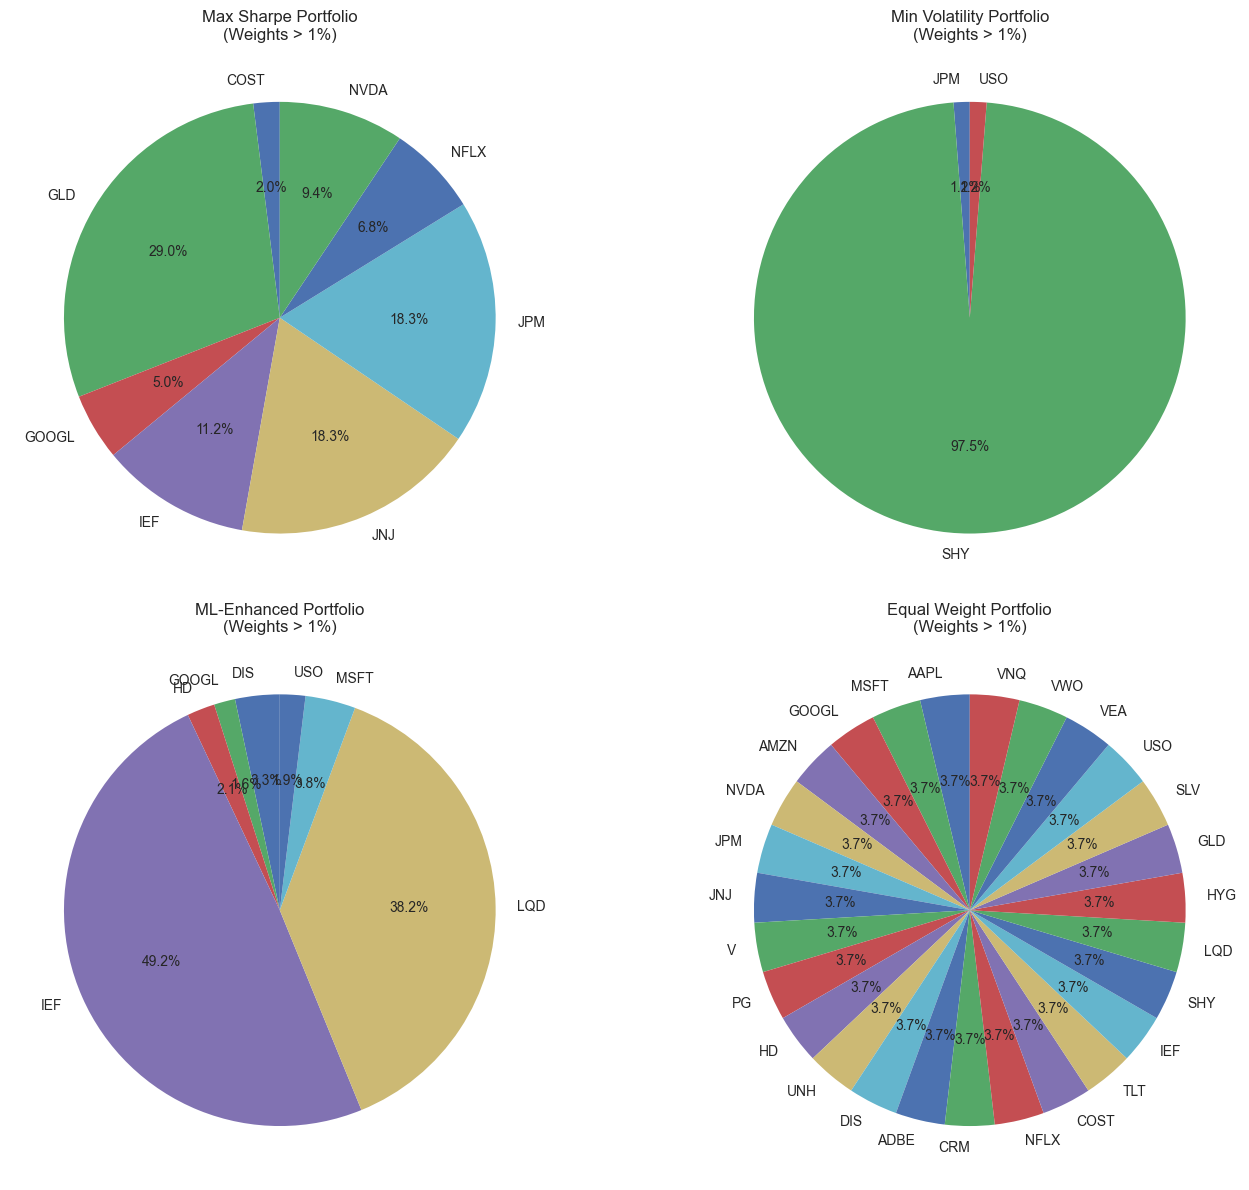


BACKTESTING SUMMARY

Equal Weight:
  Total Return: 49.7%
  Volatility: 12.6%
  Max Drawdown: -14.7%

Max Sharpe (MPT):
  Total Return: 106.5%
  Volatility: 12.3%
  Max Drawdown: -11.5%

Min Volatility (MPT):
  Total Return: 13.9%
  Volatility: 1.8%
  Max Drawdown: -0.8%

ML-Enhanced:
  Total Return: 30.9%
  Volatility: 6.9%
  Max Drawdown: -6.8%


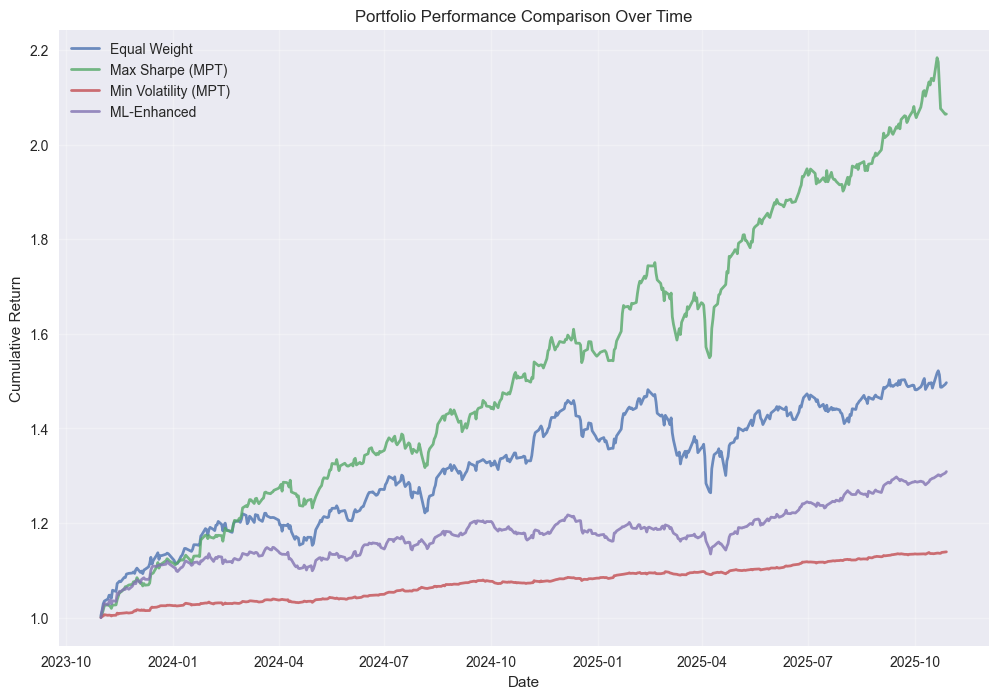

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

portfolios = [
    ('Max Sharpe Portfolio', max_sharpe['weights'], axes[0,0]),
    ('Min Volatility Portfolio', min_vol['weights'], axes[0,1]),
    ('ML-Enhanced Portfolio', ml_weights, axes[1,0]),
    ('Equal Weight Portfolio', {asset: 1/len(tickers) for asset in tickers}, axes[1,1])
]

for title, weights, ax in portfolios:
    weights_series = pd.Series(weights)
    significant_weights = weights_series[weights_series > 0.01]
    
    if len(significant_weights) > 0:
        ax.pie(significant_weights.values, labels=significant_weights.index, 
               autopct='%1.1f%%', startangle=90)
        ax.set_title(f'{title}\n(Weights > 1%)')
    else:
        ax.text(0.5, 0.5, 'No significant\nweights', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("BACKTESTING SUMMARY")
print("="*50)

def backtest_portfolio(weights, price_data):
    weights_series = pd.Series(weights)
    weights_series = weights_series / weights_series.sum()
    
    portfolio_value = (price_data * weights_series).sum(axis=1)
    portfolio_returns = portfolio_value.pct_change().dropna()
    cumulative_returns = (1 + portfolio_returns).cumprod()
    
    return portfolio_value, portfolio_returns, cumulative_returns

plt.figure(figsize=(12, 8))

for name, weights in strategies.items():
    try:
        _, portfolio_returns, cumulative_returns = backtest_portfolio(weights, price_data)
        plt.plot(cumulative_returns.index, cumulative_returns.values, 
                label=name, linewidth=2, alpha=0.8)
        
        total_return = cumulative_returns.iloc[-1] - 1
        volatility = portfolio_returns.std() * np.sqrt(252)
        max_drawdown = (cumulative_returns / cumulative_returns.expanding().max() - 1).min()
        
        print(f"\n{name}:")
        print(f"  Total Return: {total_return:.1%}")
        print(f"  Volatility: {volatility:.1%}")
        print(f"  Max Drawdown: {max_drawdown:.1%}")
        
    except Exception as e:
        print(f"{name}: Backtesting error - {e}")

plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Portfolio Performance Comparison Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()